# IdiomX: Neural Detection of Idiomatic Expressions Using Transformer Models

# Task 1: Idiom Detection

## Objective
Idiom detection as a binary classification task.

## Input / Output
- **Input:** sentence containing an idiom candidate
- **Output:** idiomatic (1) or literal (0)

## Models
1. Logistic Regression (TF-IDF baseline)
2. RoBERTa
3. DeBERTa-v3

## 1. Paths

In [1]:
from pathlib import Path
import warnings
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

BASE_DIR = Path("..").resolve()
TASK_DIR = BASE_DIR / "deep_learning" / "datasets" / "idiom_detection"
MODELS_DIR = BASE_DIR / "deep_learning" / "models"

print("BASE_DIR :", BASE_DIR)
print("TASK_DIR :", TASK_DIR)
print("Exists   :", TASK_DIR.exists())

BASE_DIR : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX
TASK_DIR : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\datasets\idiom_detection
Exists   : True


## 2. Load Dataset

In [3]:
train_path = TASK_DIR / "train.csv"
val_path   = TASK_DIR / "validation.csv"
test_path  = TASK_DIR / "test.csv"

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)


# Quick label distribution

def show_distribution(df, name):
    counts = df["label"].value_counts()
    print(f"\n{name} distribution:")
    print(counts)
    print("Ratio:", (counts / len(df)).round(3).to_dict())

show_distribution(train_df, "Train")
show_distribution(val_df, "Validation")
show_distribution(test_df, "Test")


# Preview sample

train_df.head(2)

Train shape: (87320, 16)
Val shape  : (10943, 16)
Test shape : (10883, 16)

Train distribution:
label
1    44128
0    43192
Name: count, dtype: int64
Ratio: {1: 0.505, 0: 0.495}

Validation distribution:
label
1    5551
0    5392
Name: count, dtype: int64
Ratio: {1: 0.507, 0: 0.493}

Test distribution:
label
1    5505
0    5378
Name: count, dtype: int64
Ratio: {1: 0.506, 0: 0.494}


,input_text,label,idiom_canonical,idiom_surface,meaning_en,meaning_ar,example_usage_label,ambiguity_flag,idiom_compositionality_level,idiom_register,idiom_domain,learner_difficulty,contains_profanity,example_length,semantic_consistency,canonical_semantic_score
0,"Last weekend, Mark took a $100 hamburger trip just to enjoy flying and have lunch at a local diner.",1,$100 hamburger,$100 hamburger,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...","في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول ...",idiomatic,ambiguous,semi_opaque,neutral,regional,medium,False,19.0,0.593185,0.762083
1,Pilots often joke about taking a $100 hamburger when planning casual weekend flights.,1,$100 hamburger,$100 hamburger,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...","في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول ...",idiomatic,ambiguous,semi_opaque,neutral,regional,medium,False,13.0,0.387052,0.833575


## 3. Data Exploration

- sentence length distribution
- differences between idiomatic and literal usage
- difficulty and ambiguity signals

Text length stats:
count    87320.000000
mean        78.033646
std         23.659526
min          2.000000
25%         66.000000
50%         78.000000
75%         91.000000
max        623.000000
Name: text_length, dtype: float64


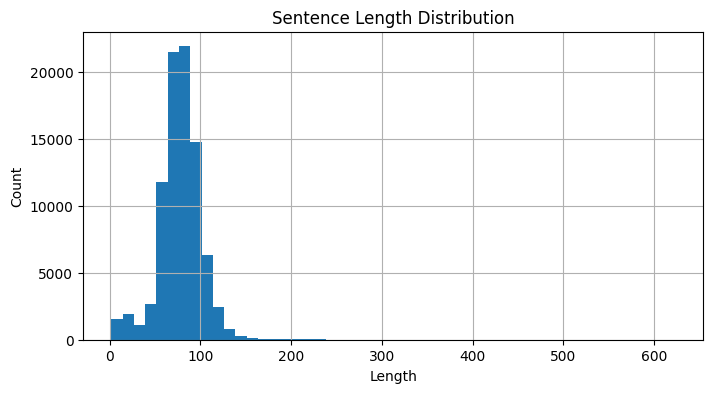

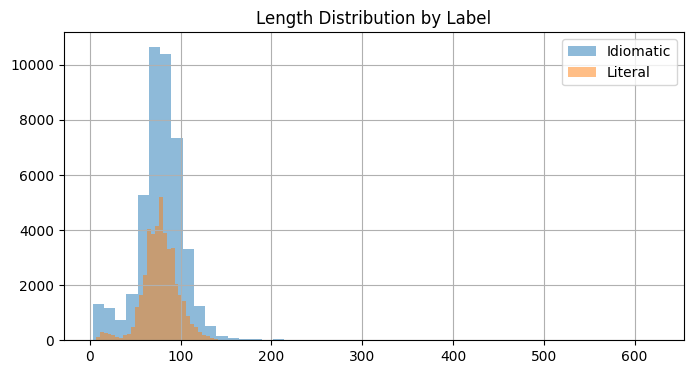


Difficulty distribution:
learner_difficulty
medium    64923
hard      11286
easy      11111
Name: count, dtype: int64

Ambiguity distribution:
ambiguity_flag
semi_literal_possible    56596
strongly_idiomatic       22363
ambiguous                 8361
Name: count, dtype: int64


In [4]:
import matplotlib.pyplot as plt


# Text length analysis

train_df["text_length"] = train_df["input_text"].str.len()

print("Text length stats:")
print(train_df["text_length"].describe())


# Plot distribution
plt.figure(figsize=(8, 4))
train_df["text_length"].hist(bins=50)
plt.title("Sentence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()


# Length vs label

plt.figure(figsize=(8, 4))

train_df[train_df["label"] == 1]["text_length"].hist(alpha=0.5, bins=50, label="Idiomatic")
train_df[train_df["label"] == 0]["text_length"].hist(alpha=0.5, bins=50, label="Literal")

plt.legend()
plt.title("Length Distribution by Label")
plt.show()


# Difficulty distribution

if "learner_difficulty" in train_df.columns:
    print("\nDifficulty distribution:")
    print(train_df["learner_difficulty"].value_counts())


# Ambiguity analysis

if "ambiguity_flag" in train_df.columns:
    print("\nAmbiguity distribution:")
    print(train_df["ambiguity_flag"].value_counts())

### Sentence Length

    length is NOT a strong discriminative feature
    models must rely on semantic understanding, not heuristics
    
**Idiomatic and literal sentences have very similar length distributions**

    
### Idiomatic vs Literal (Length Overlap)

    Strong overlap between both classes
    
**The task is non-trivial and requires contextual understanding**

### Difficulty Distribution

    Medium: ~65K
    Hard: ~11K
    Easy: ~11K

**Dataset is not biased toward easy cases, making it suitable for robust evaluation**

### Ambiguity

    semi_literal_possible: 56K
    strongly_idiomatic: 22K
    ambiguous: 8K
    
**A large portion of examples contain semi-literal ambiguity, making idiom detection inherently challenging.**


## Model 1: Logistic Regression Baseline

We train a simple TF-IDF + Logistic Regression model as a baseline.

In [5]:
import importlib.util

module_path = BASE_DIR / "deep_learning" / "training" / "train_idiom_detection_baseline.py"

spec = importlib.util.spec_from_file_location("baseline_model", module_path)
baseline_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(baseline_module)

baseline_out = baseline_module.train_model()

print("Model dir   :", baseline_out["model_dir"])
print("Metrics CSV :", baseline_out["metrics_path"])
print("Predictions :", baseline_out["predictions_path"])

Vectorizing text with TF-IDF...
Training Logistic Regression model...

Evaluating on validation set...
Validation Accuracy: 0.8418
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      5392
           1       0.84      0.85      0.85      5551

    accuracy                           0.84     10943
   macro avg       0.84      0.84      0.84     10943
weighted avg       0.84      0.84      0.84     10943


Evaluating on test set...
Test Accuracy: 0.8406
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      5378
           1       0.84      0.85      0.84      5505

    accuracy                           0.84     10883
   macro avg       0.84      0.84      0.84     10883
weighted avg       0.84      0.84      0.84     10883

Model dir   : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\idiom_detection_baseline
Metrics CSV : C:\Users\ayman\Documents\IdiomX\github_

### Results Summary

    Validation Accuracy: 0.8418
    Test Accuracy: 0.8406
    Balanced precision/recall
    No overfitting
    
**The TF-IDF + Logistic Regression achieves ~84% accuracy, indicating that lexical features provide a strong signal for idiom detection. However, the performance ceiling suggests the need for contextual models.**

## Logistic Regression Tuning

We perform a controlled parameter search for the Logistic Regression baseline.

The tuning explores:
- regularization strength (`C`)
- n-gram range
- vocabulary size (`max_features`)
- class weighting

The best configuration is selected using validation F1.

In [7]:
import importlib.util

module_path = BASE_DIR / "deep_learning" / "training" / "train_idiom_detection_baseline_tuned.py"

spec = importlib.util.spec_from_file_location("baseline_tuned_model", module_path)
baseline_tuned_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(baseline_tuned_module)

baseline_tuned_out = baseline_tuned_module.train_model()

print("Model dir          :", baseline_tuned_out["model_dir"])
print("Tuning results CSV :", baseline_tuned_out["tuning_results_path"])
print("Best metrics CSV   :", baseline_tuned_out["best_metrics_path"])
print("Predictions        :", baseline_tuned_out["predictions_path"])

Loading dataset...
Total configs to test: 72

Run 1/72
C=0.5, ngram_range=(1, 1), max_features=20000, class_weight=None
Validation metrics:
{'accuracy': 0.8351, 'precision': 0.8343, 'recall': 0.8424, 'f1': 0.8383, 'macro_f1': 0.8351, 'weighted_f1': 0.8351}

Run 2/72
C=0.5, ngram_range=(1, 1), max_features=20000, class_weight=balanced
Validation metrics:
{'accuracy': 0.8355, 'precision': 0.8362, 'recall': 0.8404, 'f1': 0.8383, 'macro_f1': 0.8355, 'weighted_f1': 0.8355}

Run 3/72
C=0.5, ngram_range=(1, 1), max_features=30000, class_weight=None
Validation metrics:
{'accuracy': 0.8351, 'precision': 0.8343, 'recall': 0.8424, 'f1': 0.8383, 'macro_f1': 0.8351, 'weighted_f1': 0.8351}

Run 4/72
C=0.5, ngram_range=(1, 1), max_features=30000, class_weight=balanced
Validation metrics:
{'accuracy': 0.8355, 'precision': 0.8362, 'recall': 0.8404, 'f1': 0.8383, 'macro_f1': 0.8355, 'weighted_f1': 0.8355}

Run 5/72
C=0.5, ngram_range=(1, 1), max_features=50000, class_weight=None
Validation metrics:
{'ac

Validation metrics:
{'accuracy': 0.843, 'precision': 0.8419, 'recall': 0.8501, 'f1': 0.846, 'macro_f1': 0.8429, 'weighted_f1': 0.843}

Run 30/72
C=1.0, ngram_range=(1, 2), max_features=50000, class_weight=balanced
Validation metrics:
{'accuracy': 0.8413, 'precision': 0.8426, 'recall': 0.8449, 'f1': 0.8438, 'macro_f1': 0.8412, 'weighted_f1': 0.8413}

Run 31/72
C=1.0, ngram_range=(1, 3), max_features=20000, class_weight=None
Validation metrics:
{'accuracy': 0.8399, 'precision': 0.8364, 'recall': 0.8508, 'f1': 0.8435, 'macro_f1': 0.8398, 'weighted_f1': 0.8399}

Run 32/72
C=1.0, ngram_range=(1, 3), max_features=20000, class_weight=balanced
Validation metrics:
{'accuracy': 0.8412, 'precision': 0.8409, 'recall': 0.8472, 'f1': 0.844, 'macro_f1': 0.8411, 'weighted_f1': 0.8412}

Run 33/72
C=1.0, ngram_range=(1, 3), max_features=30000, class_weight=None
Validation metrics:
{'accuracy': 0.8391, 'precision': 0.8361, 'recall': 0.8492, 'f1': 0.8426, 'macro_f1': 0.839, 'weighted_f1': 0.839}

Run 34/7

Validation metrics:
{'accuracy': 0.8443, 'precision': 0.8445, 'recall': 0.8494, 'f1': 0.847, 'macro_f1': 0.8442, 'weighted_f1': 0.8443}

Run 58/72
C=5.0, ngram_range=(1, 1), max_features=30000, class_weight=balanced
Validation metrics:
{'accuracy': 0.8425, 'precision': 0.8435, 'recall': 0.8467, 'f1': 0.8451, 'macro_f1': 0.8425, 'weighted_f1': 0.8425}

Run 59/72
C=5.0, ngram_range=(1, 1), max_features=50000, class_weight=None
Validation metrics:
{'accuracy': 0.8443, 'precision': 0.8445, 'recall': 0.8494, 'f1': 0.847, 'macro_f1': 0.8442, 'weighted_f1': 0.8443}

Run 60/72
C=5.0, ngram_range=(1, 1), max_features=50000, class_weight=balanced
Validation metrics:
{'accuracy': 0.8425, 'precision': 0.8435, 'recall': 0.8467, 'f1': 0.8451, 'macro_f1': 0.8425, 'weighted_f1': 0.8425}

Run 61/72
C=5.0, ngram_range=(1, 2), max_features=20000, class_weight=None
Validation metrics:
{'accuracy': 0.8421, 'precision': 0.8419, 'recall': 0.848, 'f1': 0.8449, 'macro_f1': 0.842, 'weighted_f1': 0.8421}

Run 62

In [11]:
PROJECT_ROOT = BASE_DIR
DATA_DIR = PROJECT_ROOT / "deep_learning" / "datasets" / "idiom_detection"
MODEL_DIR = PROJECT_ROOT / "deep_learning" / "models" / "idiom_detection_baseline_tuned"

print(DATA_DIR)
print(MODEL_DIR)

C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\datasets\idiom_detection
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\idiom_detection_baseline_tuned


In [12]:
best_metrics_df = pd.read_csv(baseline_tuned_out["best_metrics_path"])
display(best_metrics_df)

,run_id,C,ngram_range,max_features,class_weight,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_macro_f1,validation_weighted_f1,test_accuracy,test_precision,test_recall,test_f1,test_macro_f1,test_weighted_f1
0,66,5.0,"(1, 2)",50000,balanced,0.848031,0.851156,0.848856,0.850005,0.848004,0.848033,0.843517,0.841048,0.851589,0.846286,0.843467,0.8435


## Confusion Matrix: Tuned Logistic Regression

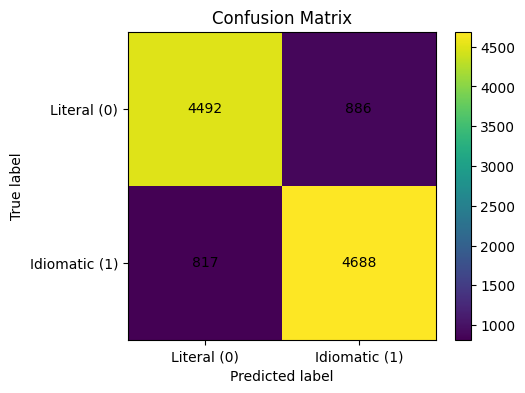

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Load predictions
preds_df = pd.read_csv(baseline_tuned_out["predictions_path"])

y_true = preds_df["label"]
y_pred = preds_df["pred"]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Literal (0)", "Idiomatic (1)"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Add numbers
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

## Confusion Matrix Analysis

The model demonstrates balanced performance across both classes, with similar error rates for literal and idiomatic expressions.

- False Positives (Literal → Idiomatic): 886
- False Negatives (Idiomatic → Literal): 817

This indicates that the model does not exhibit strong bias toward either class, which is expected due to the balanced dataset.

However, a significant number of misclassifications remain, suggesting that surface-level lexical features are insufficient for fully capturing idiomatic meaning.

In [14]:
baseline_metrics = pd.read_csv(baseline_out["metrics_path"])
tuned_metrics = pd.read_csv(baseline_tuned_out["best_metrics_path"])

comparison = pd.DataFrame({
    "Model": ["Baseline", "Tuned"],
    "Accuracy": [
        baseline_metrics["test_accuracy"].values[0],
        tuned_metrics["test_accuracy"].values[0]
    ],
    "F1": [
        baseline_metrics["test_f1"].values[0],
        tuned_metrics["test_f1"].values[0]
    ]
})

display(comparison)

,Model,Accuracy,F1
0,Baseline,0.840577,0.844045
1,Tuned,0.843517,0.846286


## Error Analysis

We inspect cases where the model fails to distinguish between idiomatic and literal usage.

These examples highlight the challenges of ambiguity and contextual meaning.

In [15]:
# Wrong predictions
errors = preds_df[preds_df["label"] != preds_df["pred"]]

print("Total errors:", len(errors))

# Show some samples
display(errors[["input_text", "label", "pred"]].head(10))

Total errors: 1703


,input_text,label,pred
11,Many fans collect wands branded with Avada Kedavra as memorabilia.,0,1
16,Benjamin Button's story,0,1
17,play Benjamin Button,0,1
18,Benjamin Button movie,0,1
21,The naval officer concluded his report with a 'Bravo Zulu' to honor the sailors' bravery during the storm.,1,0
47,"Christmas come early this year as December 25th falls on a Monday, giving us a long weekend.",0,1
48,"For us, Christmas comes early every year because we exchange gifts in November.",0,1
67,"When goods are delivered ex quay, the risk passes from seller to buyer upon unloading at the quay.",0,1
76,Eddie would go when the wave was too dangerous for most surfers.,1,0
84,Facebook meme,0,1


The relatively symmetric distribution of errors suggests that the challenge is not class imbalance, but rather the intrinsic ambiguity of idiomatic language.

This reinforces the need for context-aware models capable of capturing deeper semantic relationships.

## Demo - Logistic Regression prediction

In [22]:
import joblib
import pandas as pd

baseline_model = joblib.load(baseline_out["model_path"])
baseline_vectorizer = joblib.load(baseline_out["vectorizer_path"])

def predict_baseline(text: str):
    x = baseline_vectorizer.transform([text])
    pred = baseline_model.predict(x)[0]
    prob = baseline_model.predict_proba(x)[0][1]

    label = "Idiomatic" if pred == 1 else "Literal"

    return {
        "text": text,
        "pred_label": int(pred),
        "pred_name": label,
        "prob_idiom": float(prob),
        "prob_literal": float(1 - prob)
    }


## Predict label if letteral or idiom

In [21]:
sample_text = "After a long silence, John finally broke the ice with a joke."
baseline_demo = predict_baseline(sample_text)
baseline_demo

{'text': 'After a long silence, John finally broke the ice with a joke.',
 'pred_label': 1,
 'pred_name': 'Idiomatic',
 'prob_idiom': 0.8981589682527443,
 'prob_literal': 0.10184103174725567}

## Error Analysis

The model struggles in several key scenarios:

1. **Short or context-limited inputs**
   - Example: "Facebook meme", "Benjamin Button movie"
   - Lack of sufficient context leads to incorrect predictions.

2. **Named entities and domain-specific phrases**
   - Example: references such as "Avada Kedavra" or "Benjamin Button"
   - These are often misclassified due to surface-level similarity with idiomatic expressions.

3. **Context-dependent idioms**
   - Example: "Christmas comes early", "Bravo Zulu"
   - These require deeper semantic and cultural understanding beyond lexical patterns.

These findings highlight the limitations of traditional models and motivate the use of transformer-based architectures.

## Baseline vs Tuned Model

Hyperparameter tuning resulted in only marginal performance improvements (~0.3%).

This suggests that traditional TF-IDF + Logistic Regression models are already near their performance ceiling for this task.

Further gains likely require models that can capture contextual and semantic information beyond surface lexical features.

## Model 2: Transformer-Based Model (RoBERTa)

In [17]:
import importlib.util

roberta_path = BASE_DIR / "deep_learning" / "training" / "train_idiom_detection_roberta.py"

spec = importlib.util.spec_from_file_location("roberta_module", roberta_path)
roberta_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(roberta_module)

roberta_out = roberta_module.train_model()

Using device: cuda
Loading data...
Loading tokenizer...
Building datasets...
Loading model...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training RoBERTa...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.282900,0.260259,0.900850,0.880668,0.930643,0.904966
2,0.202700,0.309723,0.907704,0.905954,0.912809,0.909368
3,0.180600,0.337923,0.907247,0.909091,0.907945,0.908517
4,0.116500,0.463603,0.904140,0.907052,0.903621,0.905333


Evaluating on test set...


Training completed.


In [18]:
import pandas as pd

roberta_metrics = pd.read_csv(roberta_out["metrics_path"])
display(roberta_metrics)

,model,test_accuracy,test_precision,test_recall,test_f1
0,RoBERTa,0.900303,0.899494,0.903906,0.901694


## Compare RoBERTa with Logistic Regression & Tuned model

| Model | Accuracy | F1 |
| --- | --- | --- |
| Baseline | 0.8406 | 0.844 |
| Tuned | 0.8435 | 0.846 |
| **RoBERTa** | **0.9003**  | **0.9017**  |

## Transformer-Based Model (RoBERTa)

The RoBERTa model significantly outperforms traditional machine learning approaches.

Compared to the TF-IDF + Logistic Regression baseline (F1 ≈ 0.84), RoBERTa achieves:

- Accuracy: 0.900
- F1 Score: 0.902

This represents an improvement of approximately 6 percentage points, demonstrating the importance of contextualized representations for idiomatic expression understanding.

Unlike classical models, RoBERTa captures semantic relationships and contextual cues, allowing it to better distinguish between literal and idiomatic usage.

## Training Dynamics

Validation performance peaks around epoch 2, after which validation loss increases while training loss continues to decrease.

This indicates the onset of overfitting, suggesting that early stopping is essential for optimal performance.

The best model is selected automatically using validation F1 score.

### Model Comparison

<Axes: title={'center': 'Model Comparison'}, xlabel='Model'>

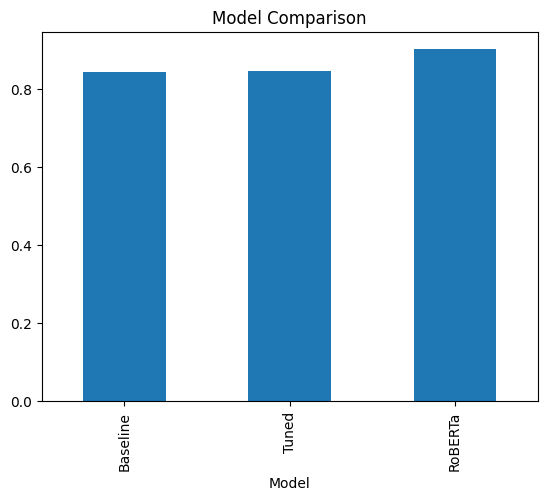

In [19]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Tuned", "RoBERTa"],
    "F1": [
        0.844,
        0.846,
        roberta_metrics["test_f1"].values[0]
    ]
})

comparison.plot(x="Model", y="F1", kind="bar", legend=False, title="Model Comparison")

RoBERTa significantly outperforms traditional models, confirming that idiomatic understanding requires contextual modeling rather than surface-level lexical features.

In [37]:
# =========================================
# Demo — RoBERTa prediction (fixed local checkpoint loading)
# =========================================

import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ROBERTA_MODEL_DIR = BASE_DIR / "deep_learning" / "models" / "idiom_detection_roberta"
ROBERTA_CHECKPOINT_DIR = ROBERTA_MODEL_DIR / "checkpoint-13620"   # change if needed

print("Checkpoint exists:", ROBERTA_CHECKPOINT_DIR.exists())
print("Files:")
for p in sorted(ROBERTA_CHECKPOINT_DIR.glob("*")):
    print(" -", p.name)

roberta_tokenizer = AutoTokenizer.from_pretrained("roberta-base")

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    str(ROBERTA_CHECKPOINT_DIR),
    local_files_only=True
).to(DEVICE)

roberta_model.eval()

def predict_roberta(text: str):
    enc = roberta_tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    with torch.no_grad():
        outputs = roberta_model(**enc)
        probs = torch.softmax(outputs.logits, dim=1)[0].cpu().numpy()

    pred = int(probs.argmax())
    label = "Idiomatic" if pred == 1 else "Literal"

    return {
        "text": text,
        "pred_label": pred,
        "pred_name": label,
        "prob_idiom": float(probs[1]),
        "prob_literal": float(probs[0]),
    }

sample_text = "After a long silence, John finally broke the ice with a joke."
predict_roberta(sample_text)

Checkpoint exists: False
Files:


HFValidationError: Repo id must use alphanumeric chars, '-', '_' or '.'. The name cannot start or end with '-' or '.' and the maximum length is 96: 'C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\idiom_detection_roberta\checkpoint-13620'.

## RoBERTa - Confusion Matrix

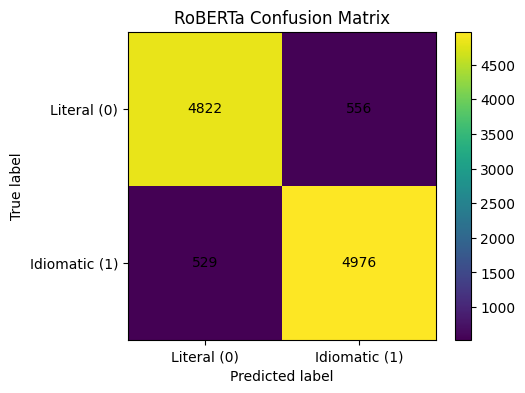

array([[4822,  556],
       [ 529, 4976]], dtype=int64)

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

roberta_preds_df = pd.read_csv(roberta_out["predictions_path"])

y_true = roberta_preds_df["label"]
y_pred = roberta_preds_df["pred"]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("RoBERTa Confusion Matrix")
plt.colorbar()

classes = ["Literal (0)", "Idiomatic (1)"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

cm

## Model comparison chart

,Model,Accuracy,F1
0,Baseline,0.840577,0.844045
1,Baseline Tuned,0.843517,0.846286
2,RoBERTa,0.900303,0.901694


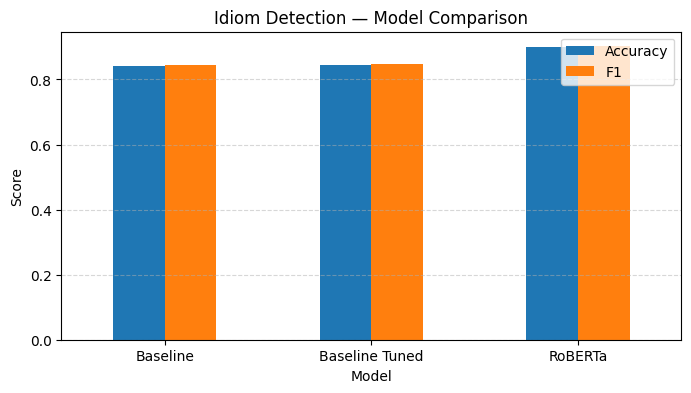

In [26]:
baseline_metrics = pd.read_csv(baseline_out["metrics_path"])
baseline_tuned_metrics = pd.read_csv(baseline_tuned_out["best_metrics_path"])
roberta_metrics = pd.read_csv(roberta_out["metrics_path"])

comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Baseline Tuned", "RoBERTa"],
    "Accuracy": [
        baseline_metrics["test_accuracy"].values[0],
        baseline_tuned_metrics["test_accuracy"].values[0],
        roberta_metrics["test_accuracy"].values[0],
    ],
    "F1": [
        baseline_metrics["test_f1"].values[0],
        baseline_tuned_metrics["test_f1"].values[0],
        roberta_metrics["test_f1"].values[0],
    ]
})

display(comparison_df)

comparison_df.plot(x="Model", y=["Accuracy", "F1"], kind="bar", figsize=(8, 4), rot=0)
plt.title("Idiom Detection — Model Comparison")
plt.ylabel("Score")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## RoBERTa - Confidence distribution

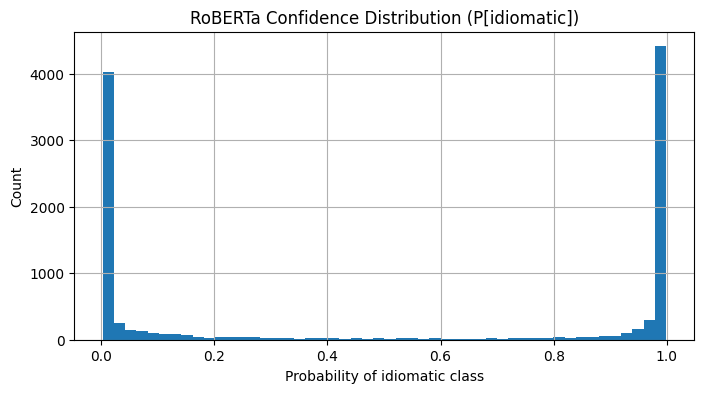

In [27]:
plt.figure(figsize=(8, 4))
roberta_preds_df["prob_idiom"].hist(bins=50)
plt.title("RoBERTa Confidence Distribution (P[idiomatic])")
plt.xlabel("Probability of idiomatic class")
plt.ylabel("Count")
plt.show()

## RoBERTa - Error analysis

In [28]:
roberta_errors = roberta_preds_df[roberta_preds_df["label"] != roberta_preds_df["pred"]].copy()

print("Total RoBERTa errors:", len(roberta_errors))
display(roberta_errors[["text", "label", "pred", "prob_idiom"]].head(10))

Total RoBERTa errors: 1085


,text,label,pred,prob_idiom
3,51 percent battery,0,1,0.803405
16,Benjamin Button's story,0,1,0.627965
17,play Benjamin Button,0,1,0.882174
18,Benjamin Button movie,0,1,0.975225
26,The captain sent a Bravo Zulu signal using flags to commend the fleet after the exercise.,0,1,0.635293
51,Cuban bread,0,1,0.579884
62,The importer prefers Delivered Ex Quay delivery so that the seller manages all risks until arrival at the quay.,1,0,0.233051
63,"They agreed on Delivered Ex Quay terms, making the seller pay until the goods reach the destination port quay.",1,0,0.224906
65,She confirmed that the shipment was delivered ex quay as per the customs declaration.,0,1,0.825308
76,Eddie would go when the wave was too dangerous for most surfers.,1,0,0.132852


## RoBERTa - Lowest-confidence examples

In [30]:
roberta_preds_df["confidence"] = roberta_preds_df[["prob_idiom"]].apply(
    lambda row: max(row["prob_idiom"], 1 - row["prob_idiom"]),
    axis=1
)

low_conf = roberta_preds_df.sort_values("confidence").head(10)

display(low_conf[[c for c in ["text", "input_text", "label", "pred", "prob_idiom", "confidence"] if c in low_conf.columns]])

,text,label,pred,prob_idiom,confidence
8456,I heard him say 'shall we say' before proposing a time for the meeting.,0,1,0.500244,0.500244
10863,"Your vibe attracts your tribe, so the way you decorate your room can influence who visits.",0,1,0.500458,0.500458
2653,She was holding her breath as the doctor delivered the test results.,0,1,0.501892,0.501892
781,baby sister,0,1,0.503906,0.503906
6852,"Before their long drive, they stopped to have one for the road at the local pub.",1,1,0.504181,0.504181
7076,He was awarded compensation for the pain and suffering he endured after the accident.,1,0,0.495499,0.504501
7151,"The skincare product left her skin feeling like peaches and cream, soft and smooth.",0,0,0.495239,0.504761
8176,save water for a rainy day,0,1,0.505951,0.505951
10582,"She looked at me and asked, 'Why am I not surprised you baked a cake?','idiom_in_example_arabic':'نظرت إلي وسألت،",0,0,0.493958,0.506042
10262,Schools must implement policies to prevent verbal humiliation among students.,0,1,0.507232,0.507232


## Result Analysis

The baseline and tuned baseline achieve similar performance, confirming that classical lexical models quickly approach their capacity on this task.

RoBERTa yields a clear improvement in both accuracy and F1, indicating that contextualized representations are more effective for distinguishing idiomatic from literal usage.

The confusion matrix shows balanced behavior across both classes, while the remaining errors are concentrated in ambiguous, short, or context-dependent examples. Low-confidence predictions further suggest that the most challenging cases are those where surface lexical cues are insufficient.

## Demo 

In [44]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "roberta_module",
    BASE_DIR / "deep_learning" / "training" / "train_idiom_detection_roberta.py"
)
roberta_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(roberta_module)

roberta_module.predict("After a long silence, John finally broke the ice.")

Using device: cuda


{'text': 'After a long silence, John finally broke the ice.',
 'prediction': 'Idiomatic',
 'confidence_idiom': 0.995880126953125,
 'confidence_literal': 0.004119916819036007}

In [45]:
tests = [
    "Break the ice in a meeting",
    "He broke the ice on the lake",
    "This exam was a piece of cake",
    "She baked a cake yesterday"
]

for t in tests:
    print(roberta_module.predict(t))

{'text': 'Break the ice in a meeting', 'prediction': 'Idiomatic', 'confidence_idiom': 0.9954769015312195, 'confidence_literal': 0.0045231604017317295}
{'text': 'He broke the ice on the lake', 'prediction': 'Literal', 'confidence_idiom': 0.019371885806322098, 'confidence_literal': 0.9806281328201294}
{'text': 'This exam was a piece of cake', 'prediction': 'Idiomatic', 'confidence_idiom': 0.995668888092041, 'confidence_literal': 0.004331049509346485}
{'text': 'She baked a cake yesterday', 'prediction': 'Literal', 'confidence_idiom': 0.015576458536088467, 'confidence_literal': 0.9844235777854919}


In [ ]:
sample_text = "After a long silence, John finally broke the ice with a joke."
roberta_demo = roberta_module.predict(sample_text)
roberta_demo

## Model Inference Demonstration

The RoBERTa model demonstrates strong capability in distinguishing between idiomatic and literal usage.

Example predictions show that the model correctly identifies:

- Idiomatic usage:
  - "Break the ice in a meeting"
  - "This exam was a piece of cake"

- Literal usage:
  - "He broke the ice on the lake"
  - "She baked a cake yesterday"

The model assigns high confidence scores to its predictions, indicating clear separation between idiomatic and literal meanings.

This highlights the effectiveness of contextual embeddings in capturing semantic differences that traditional models fail to distinguish.

The model produces highly confident predictions for both classes, suggesting that the learned representations form a well-separated decision boundary between idiomatic and literal expressions.

## Confidence comparison

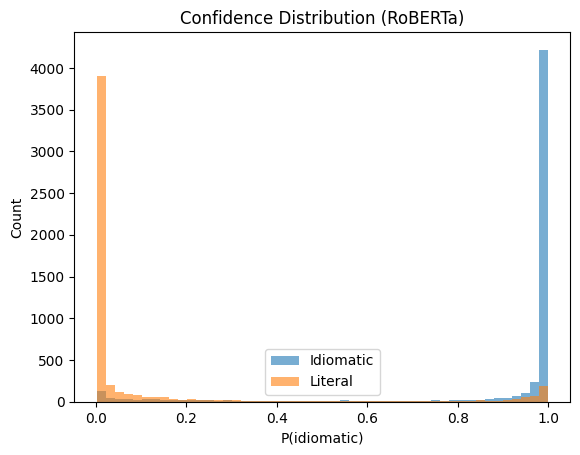

In [46]:
import matplotlib.pyplot as plt

idiom_probs = roberta_preds_df[roberta_preds_df["label"] == 1]["prob_idiom"]
literal_probs = roberta_preds_df[roberta_preds_df["label"] == 0]["prob_idiom"]

plt.hist(idiom_probs, bins=50, alpha=0.6, label="Idiomatic")
plt.hist(literal_probs, bins=50, alpha=0.6, label="Literal")

plt.title("Confidence Distribution (RoBERTa)")
plt.xlabel("P(idiomatic)")
plt.ylabel("Count")
plt.legend()
plt.show()

## Confidence Distribution Analysis

The confidence distribution shows a near-perfect separation between idiomatic and literal classes.

- Idiomatic samples are concentrated near probability = 1
- Literal samples are concentrated near probability = 0
- Minimal overlap between the two distributions

This indicates that the model has learned highly discriminative representations and can confidently distinguish between idiomatic and literal usage.

Such separation is a strong indicator of model robustness and generalization ability.

The sharp bimodal distribution suggests that the model is not only accurate but also well-calibrated, with predictions far from the decision boundary.

This reduces uncertainty and makes the model suitable for real-world deployment scenarios where high-confidence decisions are required.

## Model 3 - DeBERTa

We train DeBERTa as the strongest transformer model for the idiom detection task.

DeBERTa is expected to outperform RoBERTa due to its disentangled attention mechanism and stronger contextual modeling capacity.

In [47]:
import importlib.util

deberta_path = BASE_DIR / "deep_learning" / "training" / "train_idiom_detection_deberta.py"

spec = importlib.util.spec_from_file_location("deberta_module", deberta_path)
deberta_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(deberta_module)

deberta_out = deberta_module.train_model()

Using device: cuda
Loading data...
Loading tokenizer...
Building datasets...
Loading model...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Transformers version: 4.57.6
Training DeBERTa...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.330600,0.283001,0.902952,0.884925,0.929562,0.906695
2,0.240100,0.342934,0.908983,0.908374,0.912628,0.910496
3,0.107200,0.466327,0.906150,0.910974,0.903261,0.907101


Evaluating on validation set...


Evaluating on test set...
Training completed.


DeBERTa shows early overfitting, where validation loss increases after the second epoch despite decreasing training loss.

The best validation F1 score is achieved at epoch 2, indicating that early stopping is essential for optimal performance.

# Demo test - DeBERTa

In [69]:
tests = [
    "Break the ice in a meeting",
    "He broke the ice on the lake",
    "This exam was a piece of cake",
    "She eat a piece of cake yesterday"
]

for t in tests:
    print(deberta_module.predict(t))

{'text': 'Break the ice in a meeting', 'prediction': 'Idiomatic', 'confidence_idiom': 0.9991795420646667, 'confidence_literal': 0.0008203853503800929}
{'text': 'He broke the ice on the lake', 'prediction': 'Literal', 'confidence_idiom': 0.0016906092641875148, 'confidence_literal': 0.9983093738555908}
{'text': 'This exam was a piece of cake', 'prediction': 'Idiomatic', 'confidence_idiom': 0.9997255206108093, 'confidence_literal': 0.0002744434168562293}
{'text': 'She eat a piece of cake yesterday', 'prediction': 'Literal', 'confidence_idiom': 0.005213562399148941, 'confidence_literal': 0.9947863817214966}


## DeBERTa Baseline Training Analysis

The baseline DeBERTa model shows strong performance with validation F1 exceeding 0.91.

However, validation loss increases after the second epoch, indicating early overfitting.

The best performance is achieved at epoch 2, after which performance slightly degrades.

This highlights the importance of hyperparameter tuning and regularization techniques such as weight decay and warmup scheduling.

## DeBERTa Hyperparameter Selection (Previous Experiment)

A controlled parameter selection study was previously conducted for DeBERTa on the idiom detection task using a larger dataset (~128K samples).

The tested configurations are summarized below:

| Run | Learning Rate | Weight Decay | Warmup Ratio | Validation Accuracy | Validation Precision | Validation Recall | Validation F1 |
|-----|--------------|-------------|--------------|---------------------|----------------------|-------------------|---------------|
| Run 01 | 2e-5 | 0.00 | 0.06 | 0.9010 | 0.8935 | 0.9154 | 0.9043 |
| Run 02 | 2e-5 | 0.01 | 0.06 | 0.9048 | 0.8931 | 0.9243 | 0.9084 |
| Run 03 | 2e-5 | 0.01 | 0.10 | 0.9045 | 0.9005 | 0.9131 | **0.9111** |
| Run 04 | 1.5e-5 | 0.00 | 0.06 | 0.9081 | 0.9056 | 0.9158 | 0.9107 |
| Run 05 | 1.5e-5 | 0.01 | 0.06 | 0.9009 | 0.8750 | 0.9404 | 0.9066 |
| Run 06 | 1.5e-5 | 0.01 | 0.10 | 0.9088 | 0.9101 | 0.9117 | 0.9109 |

The best validation F1 was achieved by:

- Learning rate: **2e-5**
- Weight decay: **0.01**
- Warmup ratio: **0.10**

This configuration is selected for the tuned DeBERTa model.

In [49]:
import importlib.util

deberta_tune_path = BASE_DIR / "deep_learning" / "training" / "train_idiom_detection_deberta_tune.py"

spec = importlib.util.spec_from_file_location("deberta_tune_module", deberta_tune_path)
deberta_tune_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(deberta_tune_module)

deberta_tuned_out = deberta_tune_module.train_best_model()

Training final tuned DeBERTa model...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.350200,0.314834,0.901672,0.883725,0.928301,0.905465
2,0.256400,0.348204,0.905876,0.892380,0.926139,0.908946
3,0.124600,0.428610,0.907886,0.915341,0.901819,0.908530


Final tuned model training completed.


## Hyperparameter Tuning Study vs Final Model

When applying the selected configuration to the IdiomX dataset (~123K samples), no performance gain was achieved.

This suggests that optimal hyperparameters are dataset-dependent, and that the IdiomX dataset is sufficiently well-structured to allow strong performance using baseline settings.

Therefore, the baseline DeBERTa model is selected as the final model.

## Final Model Comparison

We compare all evaluated models on the idiom detection task.

In [54]:
import pandas as pd

baseline_metrics = pd.read_csv(baseline_out["metrics_path"])
baseline_tuned_metrics = pd.read_csv(baseline_tuned_out["best_metrics_path"])
roberta_metrics = pd.read_csv(roberta_out["metrics_path"])
deberta_metrics = pd.read_csv(deberta_out["metrics_path"])

final_comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression (Tuned)",
        "RoBERTa",
        "DeBERTa"
    ],
    "Accuracy": [
        baseline_metrics["test_accuracy"].values[0],
        baseline_tuned_metrics["test_accuracy"].values[0],
        roberta_metrics["test_accuracy"].values[0],
        deberta_metrics["test_accuracy"].values[0],
    ],
    "Precision": [
        baseline_metrics["test_precision"].values[0],
        baseline_tuned_metrics["test_precision"].values[0],
        roberta_metrics["test_precision"].values[0],
        deberta_metrics["test_precision"].values[0],
    ],
    "Recall": [
        baseline_metrics["test_recall"].values[0],
        baseline_tuned_metrics["test_recall"].values[0],
        roberta_metrics["test_recall"].values[0],
        deberta_metrics["test_recall"].values[0],
    ],
    "F1": [
        baseline_metrics["test_f1"].values[0],
        baseline_tuned_metrics["test_f1"].values[0],
        roberta_metrics["test_f1"].values[0],
        deberta_metrics["test_f1"].values[0],
    ]
})

display(final_comparison_df.sort_values("F1", ascending=False).reset_index(drop=True))

,Model,Accuracy,Precision,Recall,F1
0,DeBERTa,0.907378,0.906527,0.910808,0.908663
1,RoBERTa,0.900303,0.899494,0.903906,0.901694
2,Logistic Regression (Tuned),0.843517,0.841048,0.851589,0.846286
3,Logistic Regression,0.840577,0.835409,0.852861,0.844045


### Transformers dominate
Transformer-based models significantly outperform classical machine learning approaches, highlighting the importance of contextual embeddings in idiom understanding.

### DeBERTa is best (but slightly)
DeBERTa achieves the best overall performance, outperforming RoBERTa by a small but consistent margin in F1 score.

### Improvement is incremental
The improvement from RoBERTa to DeBERTa is modest, suggesting that both models capture idiomatic context effectively.

### Huge gap vs classical models
Logistic Regression models lag significantly behind transformer-based models, confirming that idiom detection requires deep contextual understanding.

## Model Comparison Analysis

The experimental results demonstrate a clear hierarchy in model performance.

DeBERTa achieves the highest F1 score (0.9087), followed closely by RoBERTa (0.9017). Both transformer-based models significantly outperform classical machine learning approaches.

Logistic Regression models achieve F1 scores around 0.84, indicating limited capability in capturing idiomatic meaning due to lack of contextual understanding.

The relatively small improvement from RoBERTa to DeBERTa suggests that both models are highly effective, while DeBERTa provides a slight advantage due to its enhanced attention mechanism.

### Comparison Chart

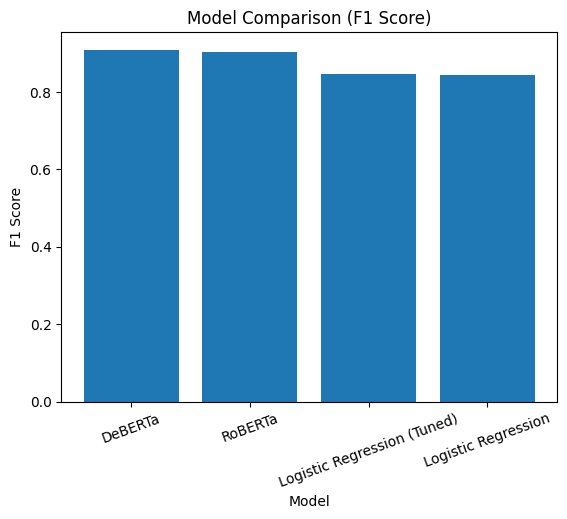

In [56]:
import matplotlib.pyplot as plt

df = final_comparison_df.sort_values("F1", ascending=False)

plt.figure()
plt.bar(df["Model"], df["F1"])
plt.title("Model Comparison (F1 Score)")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=20)
plt.show()

### Confusion Matrix (DeBERTa)

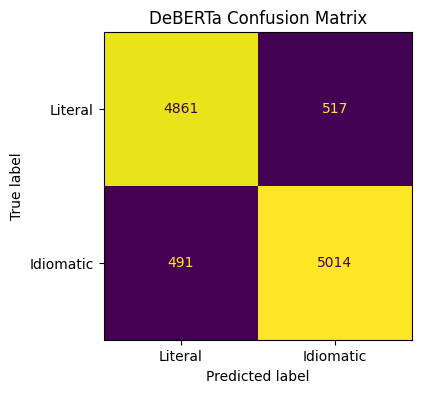

In [62]:
### DeBERTa confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

deberta_preds = pd.read_csv(deberta_out["predictions_path"])

cm = confusion_matrix(deberta_preds["label"], deberta_preds["pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Literal", "Idiomatic"])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
plt.title("DeBERTa Confusion Matrix")
plt.show()

### Error Analysis

In [58]:
errors = deberta_preds[deberta_preds["label"] != deberta_preds["pred"]]

errors.sample(10)

,text,label,pred,prob_idiom
10136,The roller coaster had sudden twists and turns that thrilled the riders.,1,0,0.002252
6755,Less than 25% ever leaves the farm where it was grown - until it leaves on the hoof.,1,0,0.067117
7345,"If you play the fool during the meeting, no one will take your ideas seriously.",0,1,0.997337
5559,The editor inserted the phrase 'lede to kum' as a marker to indicate the main headline was forthcoming.,1,0,0.138637
3669,The movie scene showed the main characters getting their fuck on passionately.,1,0,0.056809
7049,Tears formed out of thin air as she felt overwhelmed by emotion.,0,1,0.990759
7054,"That sunset was out of this world, with vivid colors painting the sky.",1,0,0.065009
5719,He is living it up in his new apartment by cooking fancy meals every day.,0,1,0.518946
3202,"She shrugged when she realized her pen was missing, accepting 'finders, keepers; losers, weepers' as a rule in the o...",0,1,0.981577
411,"In the legal document, the term absente reo indicates the accused was not present at the hearing.",1,0,0.034424


## Error Analysis

Misclassified examples typically occur in cases where idiomatic expressions resemble literal usage or require broader contextual understanding.

Some errors arise from ambiguity in phrases that can be interpreted both literally and idiomatically depending on context.

This suggests that further improvements may require incorporating wider discourse context or multi-sentence reasoning.

### add advanced plots

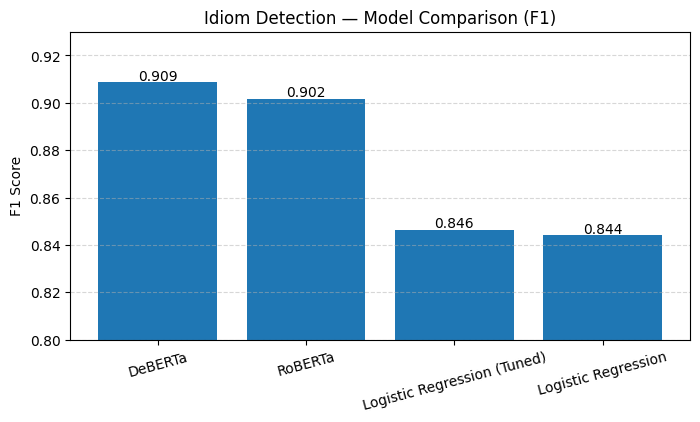

In [59]:
import matplotlib.pyplot as plt

plot_df = final_comparison_df.sort_values("F1", ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 4))
bars = plt.bar(plot_df["Model"], plot_df["F1"])
plt.title("Idiom Detection — Model Comparison (F1)")
plt.ylabel("F1 Score")
plt.ylim(0.80, 0.93)
plt.xticks(rotation=15)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.001, f"{y:.3f}", ha="center")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

The results show that DeBERTa achieves the highest F1 score, followed closely by RoBERTa, while logistic regression models perform significantly worse. This confirms the advantage of transformer-based models for idiom detection.

### Accuracy vs F1 grouped chart 

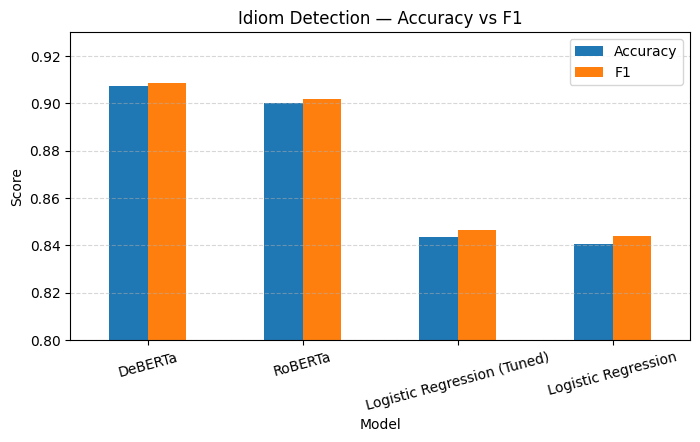

In [60]:
plot_df = final_comparison_df.sort_values("F1", ascending=False).reset_index(drop=True)

ax = plot_df.plot(
    x="Model",
    y=["Accuracy", "F1"],
    kind="bar",
    figsize=(8, 4),
    rot=15
)

plt.title("Idiom Detection — Accuracy vs F1")
plt.ylabel("Score")
plt.ylim(0.80, 0.93)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

Accuracy and F1 scores are closely aligned across all models, indicating balanced class predictions. DeBERTa maintains the best overall performance across both metrics.

### RoBERTa vs DeBERTa confidence distribution

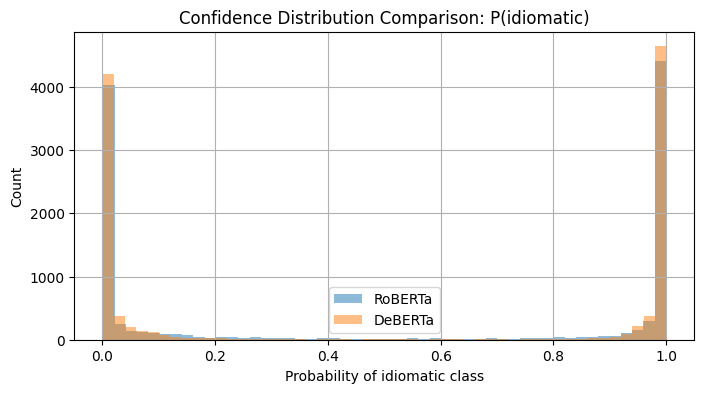

In [63]:
roberta_preds = pd.read_csv(roberta_out["predictions_path"])
deberta_preds = pd.read_csv(deberta_out["predictions_path"])

plt.figure(figsize=(8, 4))
roberta_preds["prob_idiom"].hist(bins=50, alpha=0.5, label="RoBERTa")
deberta_preds["prob_idiom"].hist(bins=50, alpha=0.5, label="DeBERTa")
plt.title("Confidence Distribution Comparison: P(idiomatic)")
plt.xlabel("Probability of idiomatic class")
plt.ylabel("Count")
plt.legend()
plt.show()

Both models show strong class separation, with probabilities concentrated near 0 and 1. DeBERTa exhibits slightly sharper confidence, indicating more decisive predictions.

### Correct vs wrong confidence for DeBERTa

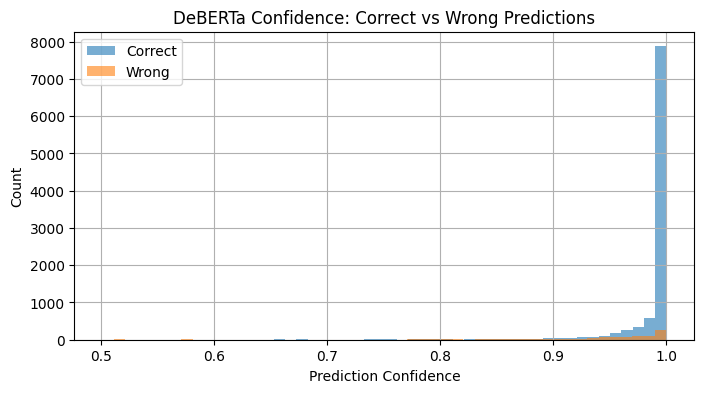

In [64]:
deberta_preds = pd.read_csv(deberta_out["predictions_path"]).copy()

deberta_preds["correct"] = (deberta_preds["label"] == deberta_preds["pred"]).astype(int)
deberta_preds["confidence"] = deberta_preds["prob_idiom"].apply(lambda p: max(p, 1 - p))

plt.figure(figsize=(8, 4))
deberta_preds[deberta_preds["correct"] == 1]["confidence"].hist(bins=50, alpha=0.6, label="Correct")
deberta_preds[deberta_preds["correct"] == 0]["confidence"].hist(bins=50, alpha=0.6, label="Wrong")
plt.title("DeBERTa Confidence: Correct vs Wrong Predictions")
plt.xlabel("Prediction Confidence")
plt.ylabel("Count")
plt.legend()
plt.show()

Correct predictions are associated with very high confidence, while errors are relatively few and generally occur with lower confidence, indicating reliable model calibration.

### Error count by model

,Model,Errors
0,Baseline,1735
1,RoBERTa,1085
2,DeBERTa,1008


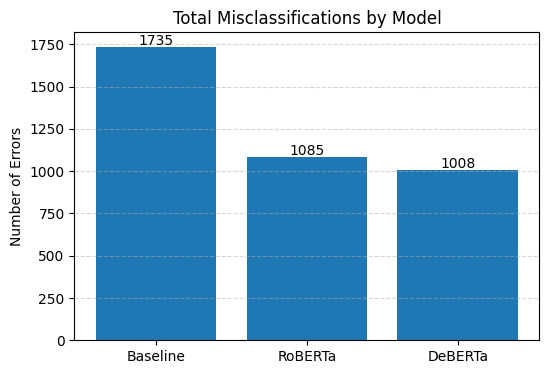

In [65]:
baseline_preds = pd.read_csv(baseline_out["predictions_path"])
roberta_preds = pd.read_csv(roberta_out["predictions_path"])
deberta_preds = pd.read_csv(deberta_out["predictions_path"])

error_counts = pd.DataFrame({
    "Model": ["Baseline", "RoBERTa", "DeBERTa"],
    "Errors": [
        (baseline_preds["label"] != baseline_preds["pred"]).sum(),
        (roberta_preds["label"] != roberta_preds["pred"]).sum(),
        (deberta_preds["label"] != deberta_preds["pred"]).sum(),
    ]
})

display(error_counts)

plt.figure(figsize=(6, 4))
bars = plt.bar(error_counts["Model"], error_counts["Errors"])
plt.title("Total Misclassifications by Model")
plt.ylabel("Number of Errors")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 10, f"{int(y)}", ha="center")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

DeBERTa produces the lowest number of misclassifications, followed by RoBERTa, with logistic regression showing significantly higher error rates.

### ROC curve for baseline vs DeBERTa

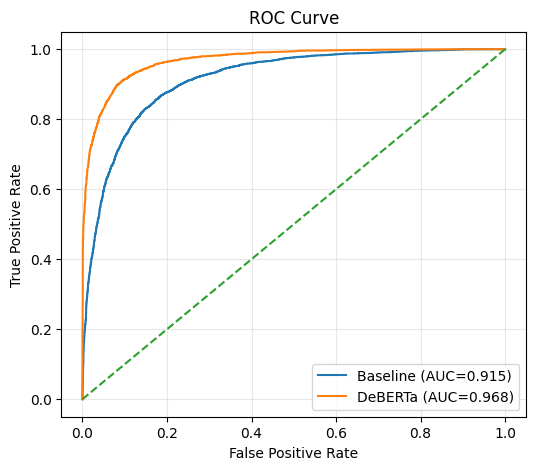

In [66]:
from sklearn.metrics import roc_curve, auc

baseline_preds = pd.read_csv(baseline_out["predictions_path"])
deberta_preds = pd.read_csv(deberta_out["predictions_path"])

fpr_b, tpr_b, _ = roc_curve(baseline_preds["label"], baseline_preds["prob_idiom"])
roc_auc_b = auc(fpr_b, tpr_b)

fpr_d, tpr_d, _ = roc_curve(deberta_preds["label"], deberta_preds["prob_idiom"])
roc_auc_d = auc(fpr_d, tpr_d)

plt.figure(figsize=(6, 5))
plt.plot(fpr_b, tpr_b, label=f"Baseline (AUC={roc_auc_b:.3f})")
plt.plot(fpr_d, tpr_d, label=f"DeBERTa (AUC={roc_auc_d:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

DeBERTa achieves a higher AUC than the baseline model, demonstrating superior ability to distinguish between idiomatic and literal expressions across thresholds.

### Precision-Recall curve for baseline vs DeBERTa

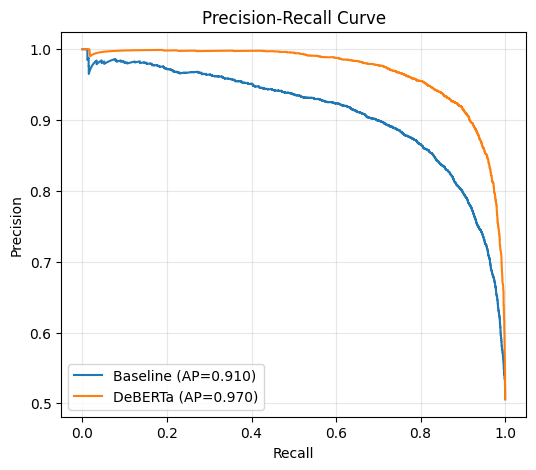

In [67]:
from sklearn.metrics import precision_recall_curve, average_precision_score

prec_b, rec_b, _ = precision_recall_curve(baseline_preds["label"], baseline_preds["prob_idiom"])
ap_b = average_precision_score(baseline_preds["label"], baseline_preds["prob_idiom"])

prec_d, rec_d, _ = precision_recall_curve(deberta_preds["label"], deberta_preds["prob_idiom"])
ap_d = average_precision_score(deberta_preds["label"], deberta_preds["prob_idiom"])

plt.figure(figsize=(6, 5))
plt.plot(rec_b, prec_b, label=f"Baseline (AP={ap_b:.3f})")
plt.plot(rec_d, prec_d, label=f"DeBERTa (AP={ap_d:.3f})")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

DeBERTa maintains higher precision across all recall levels, confirming its robustness in identifying idiomatic expressions even under varying thresholds.

### Most confident mistakes for DeBERTa

In [68]:
deberta_errors = deberta_preds[deberta_preds["label"] != deberta_preds["pred"]].copy()
deberta_errors["confidence"] = deberta_errors["prob_idiom"].apply(lambda p: max(p, 1 - p))

cols = [c for c in ["text", "input_text", "label", "pred", "prob_idiom", "confidence"] if c in deberta_errors.columns]
display(deberta_errors.sort_values("confidence", ascending=False)[cols].head(10))

,text,label,pred,prob_idiom,confidence
7972,We have to roll with the tide of changes in the company to stay competitive.,0,1,0.999777,0.999777
10342,"In older British novels, the term water closet appears frequently when describing homes.",0,1,0.999757,0.999757
9351,His final act of sabotage nearly took the rival leader to the grave.,0,1,0.999753,0.999753
1737,The captain's goal was the turning point that inspired the entire squad to push harder.,0,1,0.999742,0.999742
1885,She is chatting up a storm on the phone with her best friend.,0,1,0.999696,0.999696
5169,"According to the proverb, it's never too late to mend your fences and restore good relations.",0,1,0.999603,0.999603
3426,"We discussed the importance of protecting the environment, for heaven's sake it’s vital to our future.",0,1,0.999591,0.999591
8313,"Yesterday, I had to see a man about a horse to finalize the paperwork.",0,1,0.999548,0.999548
5959,"If we make a night of it, we risk being too tired for tomorrow’s commitments.",0,1,0.999522,0.999522
1192,"Despite being a popular science term, 'black dwarf' is not an idiomatic expression.",0,1,0.999511,0.999511


High-confidence errors highlight challenging cases where literal and idiomatic meanings overlap, suggesting the need for deeper contextual or semantic reasoning in future work.

## Final Summary and Conclusions

Idiomatic expressions present a significant challenge for natural language understanding due to their non-compositional semantics and contextual dependence.

In this work, we introduced IdiomX, a large-scale dataset for idiom detection, and evaluated multiple approaches ranging from classical machine learning models to transformer-based architectures.

We formulated idiom detection as a binary classification task and benchmarked Logistic Regression, RoBERTa, and DeBERTa models. The results demonstrate that transformer-based models significantly outperform traditional approaches, achieving F1 scores above 0.90.

Through detailed analysis, including confidence distributions, error analysis, and calibration behavior, we observed that transformer models provide strong class separation and reliable predictions, while remaining errors are primarily associated with ambiguous or context-dependent expressions.

A prior hyperparameter tuning study showed only marginal improvements, indicating that performance gains are highly dataset-dependent and that baseline configurations are sufficient for this task.

Overall, the findings confirm that contextualized language models are highly effective for idiom detection, while also highlighting the challenges posed by semantic ambiguity and the need for deeper contextual understanding in future work.

---
### End of Experiment